In [6]:
print("Coucou")

Coucou


### Détection et Nettoyage des Outliers

#### Importation des librairies

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#### 1. Chargement des données (attention au séparateur ';' de votre fichier)

In [8]:
df = pd.read_csv('./data/train.csv', sep=',')

#### 2. Visualisation initiale : GrLivArea vs SalePrice

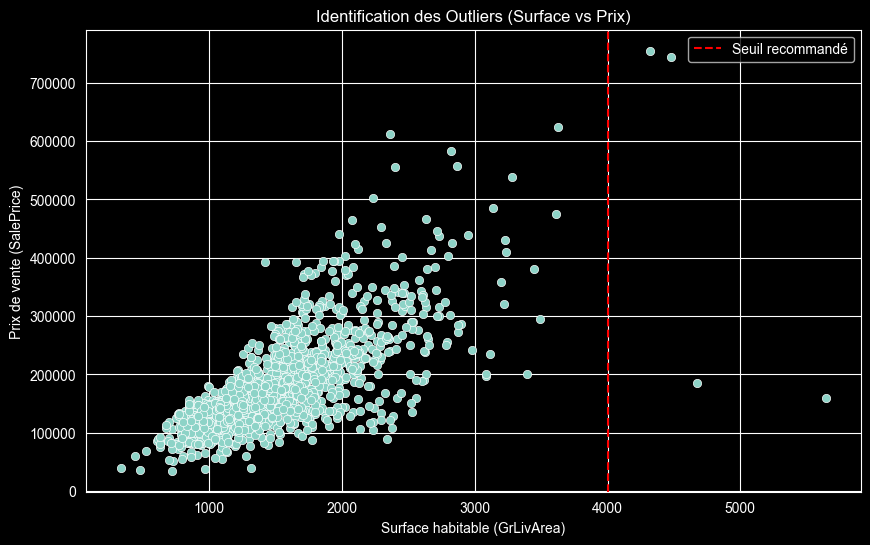

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.title("Identification des Outliers (Surface vs Prix)")
plt.xlabel("Surface habitable (GrLivArea)")
plt.ylabel("Prix de vente (SalePrice)")
plt.axvline(x=4000, color='r', linestyle='--', label='Seuil recommandé')
plt.legend()
plt.show()

#### 3. Suppression des valeurs aberrantes
On cible les maisons > 4000 sq ft qui ont un prix anormalement bas

In [10]:
outliers_index = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index
print(f"Nombre de points supprimés : {len(outliers_index)}")

df_cleaned = df.drop(outliers_index)

Nombre de points supprimés : 2


#### 4. Visualisation après nettoyage

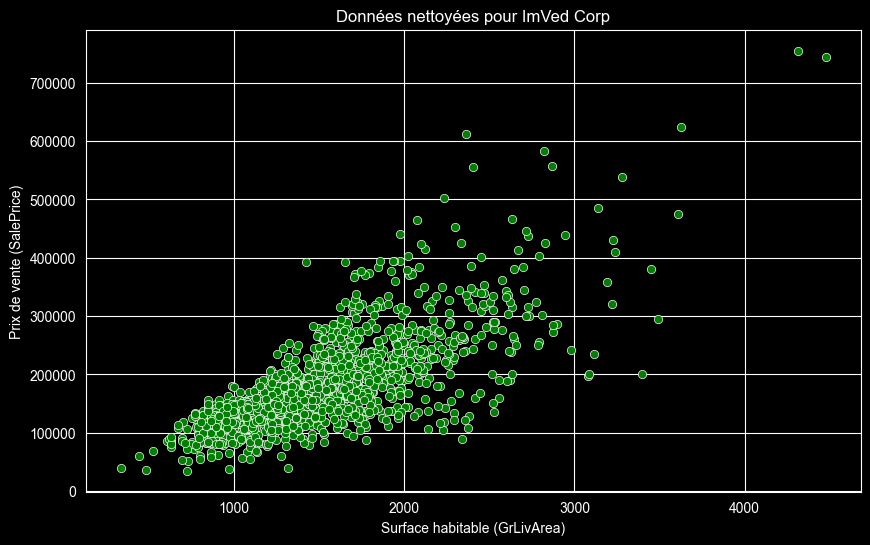

Statistiques après nettoyage :
         GrLivArea      SalePrice
count  1458.000000    1458.000000
mean   1510.465706  180932.919067
std     507.878508   79495.055285
min     334.000000   34900.000000
25%    1128.500000  129925.000000
50%    1461.500000  163000.000000
75%    1776.000000  214000.000000
max    4476.000000  755000.000000


In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_cleaned['GrLivArea'], y=df_cleaned['SalePrice'], color='green')
plt.title("Données nettoyées pour ImVed Corp")
plt.xlabel("Surface habitable (GrLivArea)")
plt.ylabel("Prix de vente (SalePrice)")
plt.show()

# 5. Application de la transformation logarithmique sur la cible
# (Indispensable pour la métrique RMSE sur logs demandée)
df_cleaned['SalePrice_Log'] = np.log1p(df_cleaned['SalePrice'])

print("Statistiques après nettoyage :")
print(df_cleaned[['GrLivArea', 'SalePrice']].describe())

#### Imputer les valeurs manquantes NA

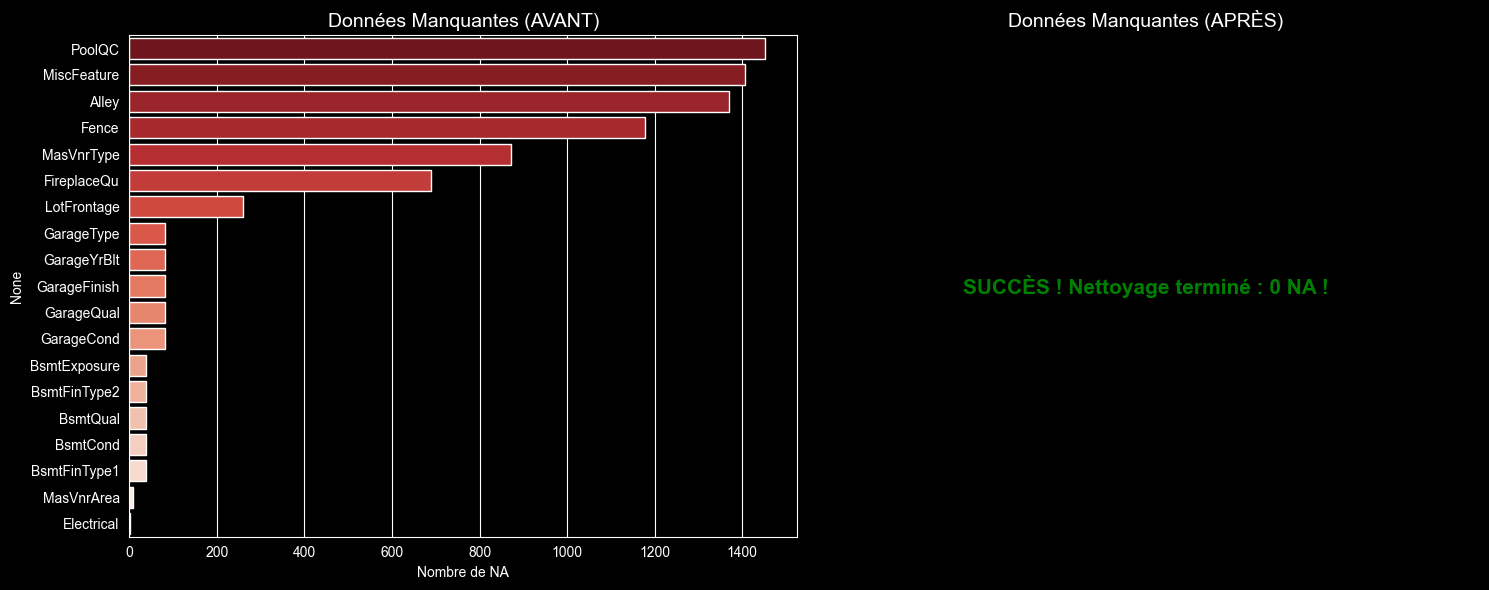

Total NA avant : 7829
Total NA après  : 0


In [12]:
# 1. Chargement des données (Séparateur spécifique ;)
df = pd.read_csv('./Data/train.csv', sep=',')

# 2. Définition de la fonction d'imputation "Intelligente"
def intelligent_imputation(df):
    df_imputed = df.copy()

    # NA = "None" (Absence d'équipement)
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                 'BsmtFinType2', 'MasVnrType']
    for col in none_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna('None')

    # NA = 0 (Absence de surface/garage)
    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath',
                 'BsmtHalfBath', 'MasVnrArea']
    for col in zero_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna(0)

    # Imputation par la médiane du quartier (LotFrontage)
    if 'LotFrontage' in df_imputed.columns and 'Neighborhood' in df_imputed.columns:
        df_imputed['LotFrontage'] = df_imputed.groupby('Neighborhood')['LotFrontage'].transform(
            lambda x: x.fillna(x.median())
        )

    # Imputation par le Mode (Valeurs les plus fréquentes)
    mode_cols = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
    for col in mode_cols:
        if col in df_imputed.columns:
            df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

    # Cas particulier Functional
    if 'Functional' in df_imputed.columns:
        df_imputed['Functional'] = df_imputed['Functional'].fillna('Typ')

    # Suppression Utilities (Trop peu d'information)
    if 'Utilities' in df_imputed.columns:
        df_imputed = df_imputed.drop(['Utilities'], axis=1)

    return df_imputed

# 3. Analyse AVANT Imputation
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0].sort_values(ascending=False)

# 4. Exécution de l'imputation
df_cleaned = intelligent_imputation(df)

# 5. Analyse APRÈS Imputation
missing_after = df_cleaned.isnull().sum()
missing_after = missing_after[missing_after > 0] # On espère que c'est vide !

# 6. Visualisation comparative
plt.figure(figsize=(15, 6))

# Graphique AVANT
plt.subplot(1, 2, 1)
if not missing_before.empty:
    sns.barplot(x=missing_before.values, y=missing_before.index, hue=missing_before.index, palette='Reds_r', legend=False)
    plt.title("Données Manquantes (AVANT)", fontsize=14)
    plt.xlabel("Nombre de NA")
else:
    plt.text(0.5, 0.5, "Aucune donnée manquante", ha='center')

# Graphique APRÈS
plt.subplot(1, 2, 2)
if not missing_after.empty:
    sns.barplot(x=missing_after.values, y=missing_after.index, hue=missing_before.index, palette='Blues_r', legend=False)
    plt.title("Données Manquantes restantes (APRÈS)", fontsize=14)
else:
    # Si tout est propre, on affiche un message de succès
    plt.text(0.5, 0.5, "SUCCÈS ! Nettoyage terminé : 0 NA !",
             ha='center', va='center', fontsize=15, color='green', fontweight='bold')
    plt.title("Données Manquantes (APRÈS)", fontsize=14)
    plt.gca().set_axis_off()

plt.tight_layout()
plt.show()

# Affichage du résumé final
print(f"Total NA avant : {missing_before.sum()}")
print(f"Total NA après  : {df_cleaned.isnull().sum().sum()}")

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# 1. Séparer les caractéristiques (X) de la cible (y)
# On retire 'SalePrice' (la cible) et 'Id' (inutile pour prédire)
X = df_cleaned.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y = df_cleaned['SalePrice']

# 2. Créer la cible en logarithme (indispensable pour votre métrique RMSE sur log)
y_log = np.log1p(y)

# 3. Découper le dataset (80% pour l'entraînement, 20% pour la validation)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Initialiser le modèle RandomForest (qui semblait manquer aussi)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

print(f"Données d'entraînement : {X_train.shape}")
print(f"Données de validation  : {X_test.shape}")

Données d'entraînement : (1168, 78)
Données de validation  : (292, 78)


In [15]:
# 1. Encodage des variables de qualité (Ordinales)
# On transforme manuellement les notes en chiffres pour garder la hiérarchie
ord_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = df_cleaned[col].map(ord_map)

# 2. Encodage des variables sans ordre (One-Hot Encoding)
# C'est ici que 'RL', 'RM', etc., deviennent des colonnes de 0 et 1
df_final = pd.get_dummies(df_cleaned)

# 3. Recréer les variables d'entraînement avec les nouvelles données numériques
X = df_final.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y_log = np.log1p(df_final['SalePrice'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. Maintenant, l'entraînement fonctionnera !
rf.fit(X_train, y_train_log)
gb.fit(X_train, y_train_log)

print("Succès : Les modèles sont entraînés !")

Succès : Les modèles sont entraînés !


In [16]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Créer un Random Forest (Équipe A)
rf = RandomForestRegressor(n_estimators=100, max_depth=10)

# Créer un Gradient Boosting (Équipe B)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)

# Entraîner sur les logs des prix pour Ames
rf.fit(X_train, y_train_log)
gb.fit(X_train, y_train_log)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

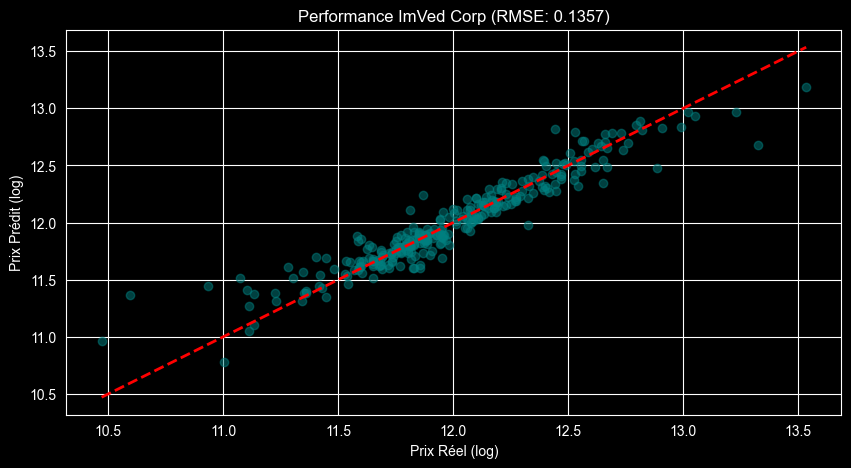

Le score RMSE final du modèle sélectionné est : 0.1357


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# --- 1. ENCODAGE (Correction de l'erreur 'RL') ---
# Transformation des variables qualitatives en chiffres
df_final = pd.get_dummies(df_cleaned)

# --- 2. PRÉPARATION DES DONNÉES ---
X = df_final.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y_log = np.log1p(df_final['SalePrice'])

# Séparation Train (80%) / Test (20%)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- 3. ENTRAÎNEMENT ---
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

rf.fit(X_train, y_train_log)
gb.fit(X_train, y_train_log)

# --- 4. ÉVALUATION ET GRAPHIQUES ---
y_pred_gb = gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test_log, y_pred_gb))

plt.figure(figsize=(10, 5))
plt.scatter(y_test_log, y_pred_gb, alpha=0.5, color='teal')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
plt.title(f"Performance ImVed Corp (RMSE: {rmse_gb:.4f})")
plt.xlabel("Prix Réel (log)")
plt.ylabel("Prix Prédit (log)")
plt.show()

print(f"Le score RMSE final du modèle sélectionné est : {rmse_gb:.4f}")

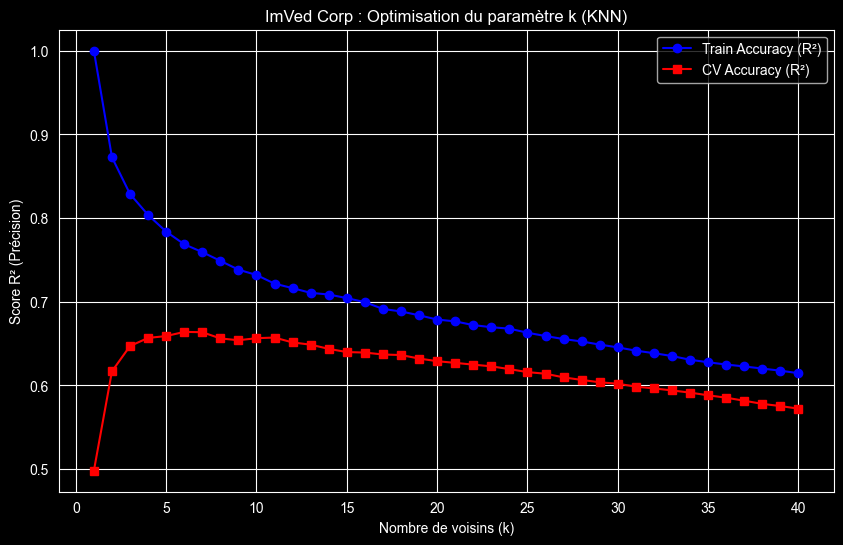

Le meilleur k pour la validation croisée est : 6


In [18]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# 1. Définir une plage de k (ex: de 1 à 40)
k_range = range(1, 41)
train_scores = []
cv_scores = []

# 2. Boucle pour tester chaque valeur de k
for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k)

    # Score d'entraînement (sur y_train_log)
    knn.fit(X_train, y_train_log)
    train_scores.append(knn.score(X_train, y_train_log))

    # Score de Validation Croisée (CV) - Moyenne de 5-folds
    scores = cross_val_score(knn, X_train, y_train_log, cv=5)
    cv_scores.append(scores.mean())

# 3. Visualisation des "Accuracies" (R² Score)
plt.figure(figsize=(10, 6))
plt.plot(k_range, train_scores, label='Train Accuracy (R²)', color='blue', marker='o')
plt.plot(k_range, cv_scores, label='CV Accuracy (R²)', color='red', marker='s')

plt.title('ImVed Corp : Optimisation du paramètre k (KNN)')
plt.xlabel('Nombre de voisins (k)')
plt.ylabel('Score R² (Précision)')
plt.legend()
plt.grid(True)
plt.show()

# Identifier le meilleur k
best_k = k_range[np.argmax(cv_scores)]
print(f"Le meilleur k pour la validation croisée est : {best_k}")